In [3]:
import pandas as pd
import numpy as np
import re
training_data_df = pd.read_csv("training_data_202601.csv")

# extract the training/validation tuples
ids = np.loadtxt("trainval_ids.txt", dtype=[("id", "i4")])
trainval_df = training_data_df[training_data_df["unique_id"].isin(ids["id"])]

f_clocks_df = trainval_df[trainval_df['Painting'] == 'The Persistence of Memory']
f_starry_df = trainval_df[trainval_df['Painting'] == 'The Starry Night']
f_lilies_df = trainval_df[trainval_df['Painting'] == 'The Water Lily Pond']

paintings = ['clocks', 'starry', 'lilies']
dfs = [f_clocks_df, f_starry_df, f_lilies_df]

In [4]:
output_files = []
for painting in paintings:
    output_files.append(("Describe how this painting makes you feel.", f'text/{painting}_feel.txt'))
    output_files.append(("If this painting was a food, what would be?", f'text/{painting}_food.txt'))
    output_files.append(("Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.", f'text/{painting}_soundtrack.txt'))
try:
    # Validate column existence
    for column_name, output_file in output_files:
        if "clocks" in output_file:
            df = f_clocks_df
        elif "starry" in output_file:
            df = starry_df
        else:
            df = lilies_df
        if column_name not in df.columns:
            raise ValueError(f"Column '{column_name}' does not exist in DataFrame.")

        # Export column to text file (one value per line)
        df[column_name].to_csv(output_file, index=False, header=False)

except (IOError, OSError) as file_error:
    print(f"File error: {file_error}")
except ValueError as val_error:
    print(f"Value error: {val_error}")
except Exception as e:
    print(f"Unexpected error: {e}")

Unexpected error: name 'starry_df' is not defined


In [5]:
from PIL import Image

clocks_coloring = np.array(Image.open("images/clocks.png"))
starry_coloring = np.array(Image.open("images/starry.png"))
lilies_coloring = np.array(Image.open("images/lilies.png"))
colorings = [clocks_coloring, starry_coloring, lilies_coloring]

In [6]:
# words to ignore for each question
general_ignore = [
    'clock', # should we ignore this one? Great predictor of one painting
    'clocks',
    'sky',
    'night' # same for these
    'something'
]

feel_ignore = [
    'feeling',
    'feelings',
    'feels',
    'felt'
]

food_ignore = [
    'foods',
    'food'
]

music_ignore = [
    'sound',
    'sounds',
    'soundtracks',
    'music',
    'song'
]

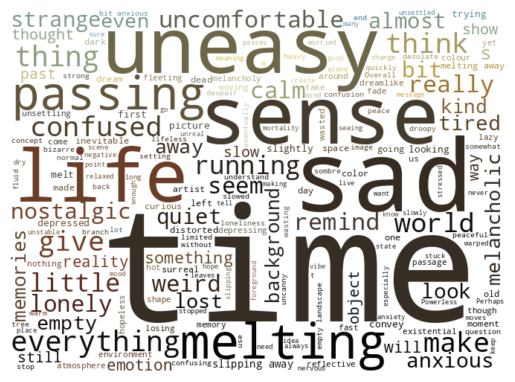

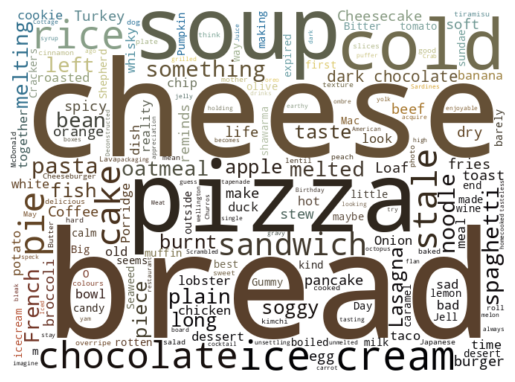

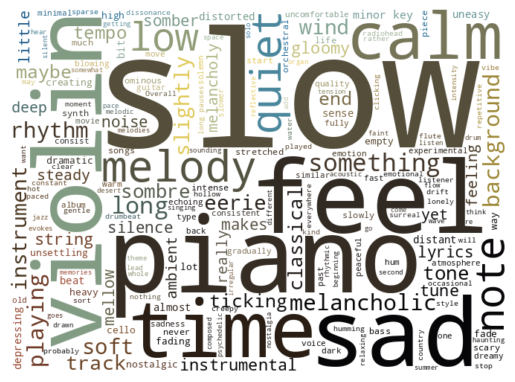

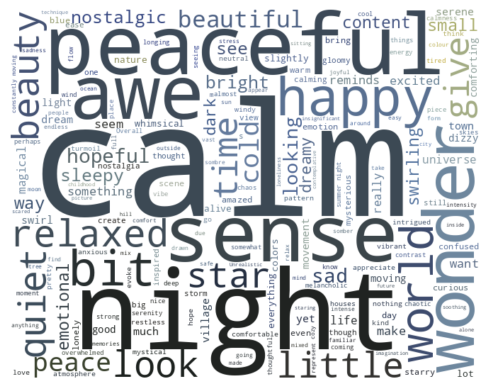

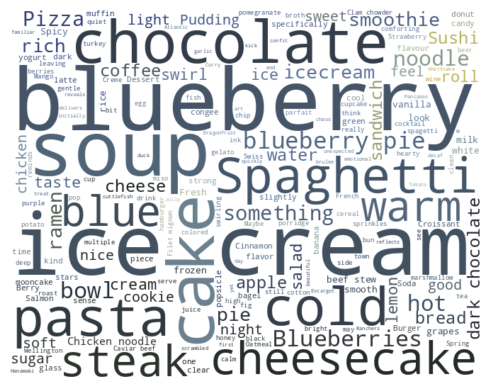

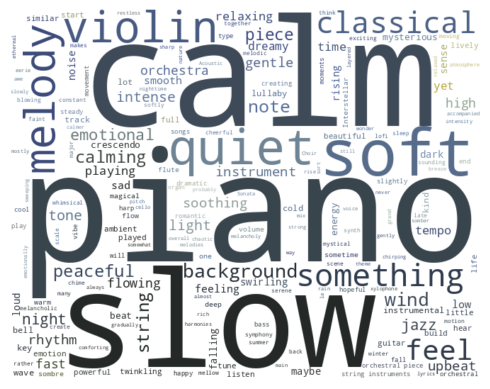

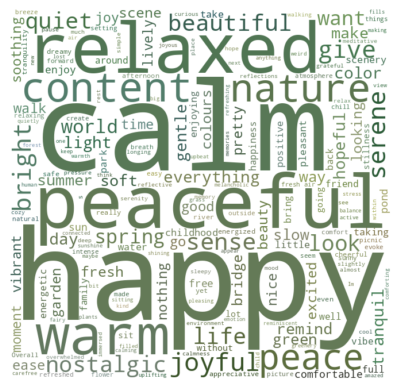

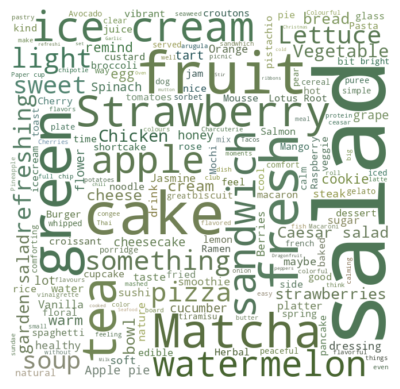

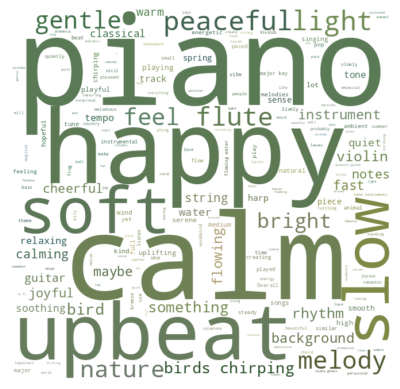

In [7]:
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt

for column_name, output_file in output_files:
    if "clocks" in output_file:
        coloring = clocks_coloring
    elif "starry" in output_file:
        coloring = starry_coloring
    else:
        coloring = lilies_coloring

    stopwords = set(WordCloud().stopwords)
    stopwords.update(general_ignore)
    for word in column_name.strip('.,!?()[]{}"\'').split():
        stopwords.add(word)
    if "feel" in column_name:
        stopwords.update(feel_ignore)
    elif "food" in column_name:
        stopwords.update(food_ignore)
    else:
        stopwords.update(music_ignore)

    with open(output_file, 'r') as file:
        text = file.read()
        wordcloud = WordCloud(stopwords=stopwords, mask=coloring, background_color='white').generate(text)

    image_colors = ImageColorGenerator(coloring)

    plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
    plt.axis("off")
    plt.show()

In [8]:
def get_counts(title, path):
  stopwords = set(base)
  stopwords.update(general_ignore)
  for word in title.strip('.,!?()[]{}"\'').split():
    stopwords.add(word)

  if "feel" in title:
    stopwords.update(feel_ignore)
  elif "food" in title:
    stopwords.update(food_ignore)
  else:
    stopwords.update(music_ignore)

  counts = dict()
  total = 0
  with open(path, 'r') as file:
    for line in file:
      for w in line.split():
        w_clean = re.sub(r"[^\w\s]", "", w.strip().lower())
        if w_clean in stopwords or w_clean == '':
          continue

        if w_clean not in counts:
          counts[w_clean] = 0
        counts[w_clean] += 1
        total += 1

  return counts, total


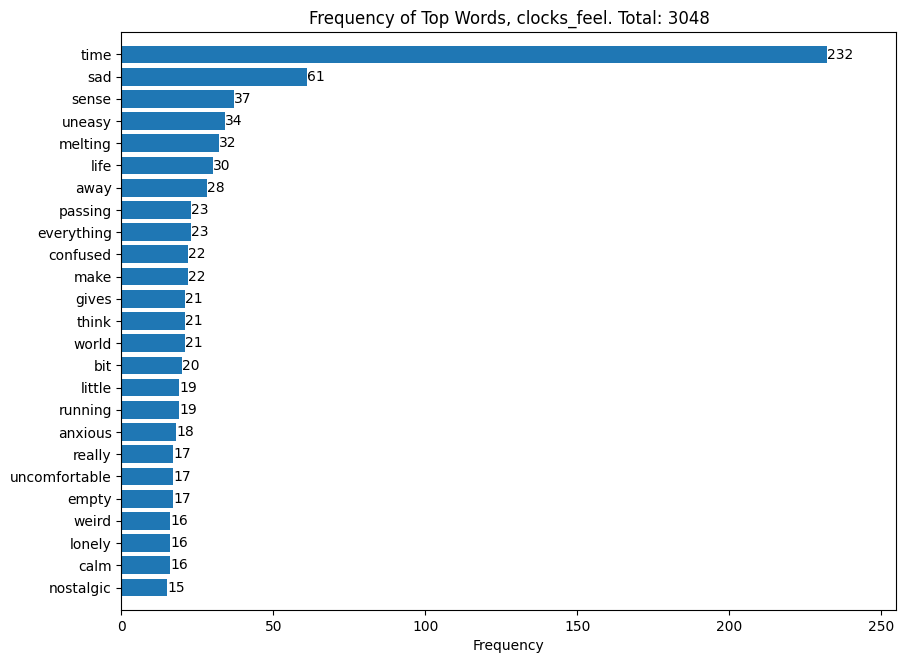

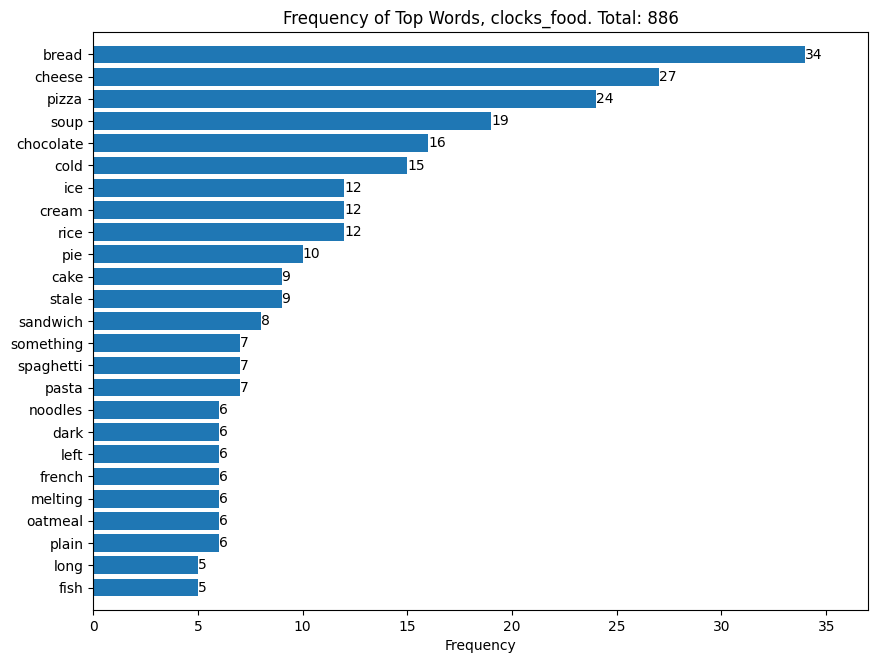

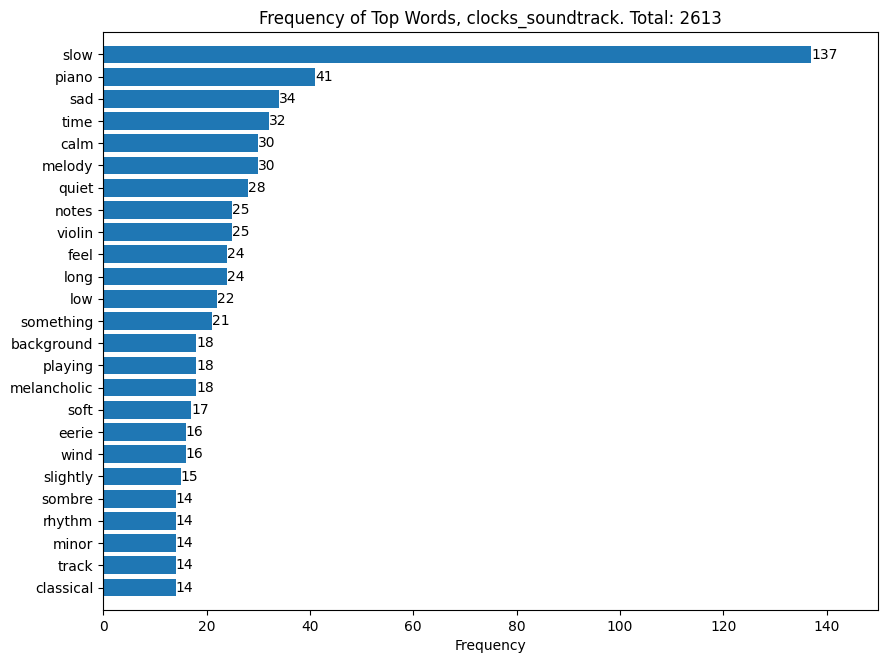

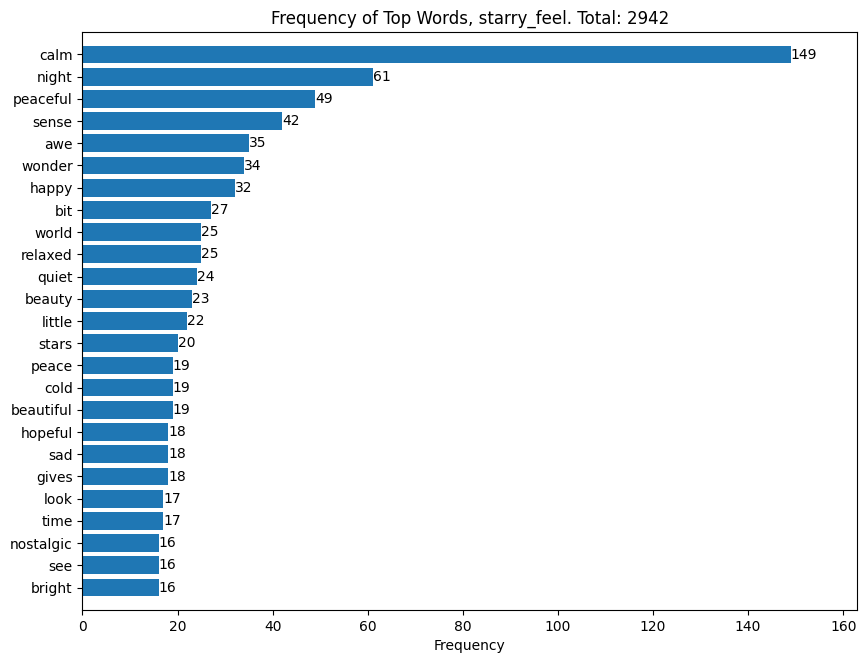

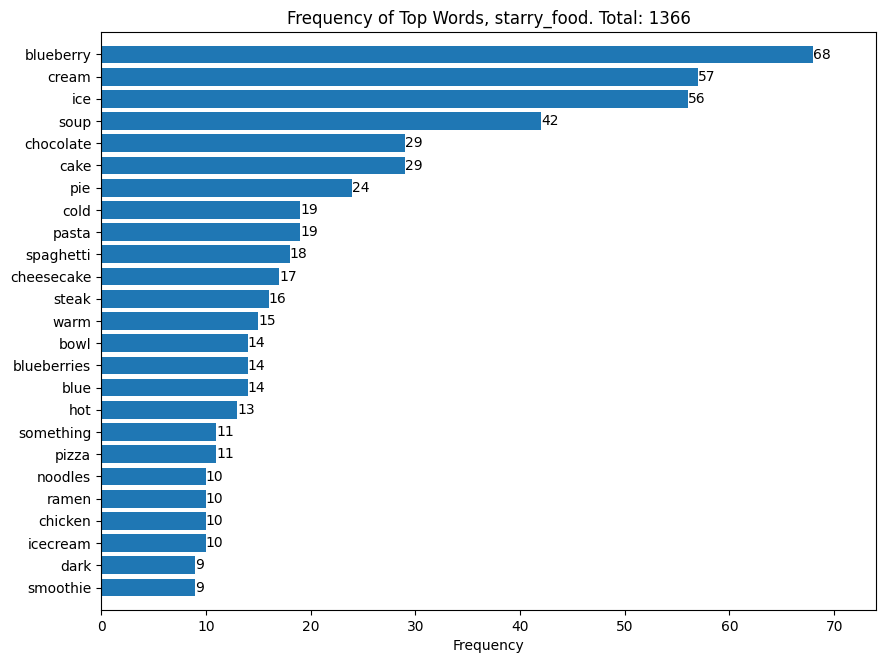

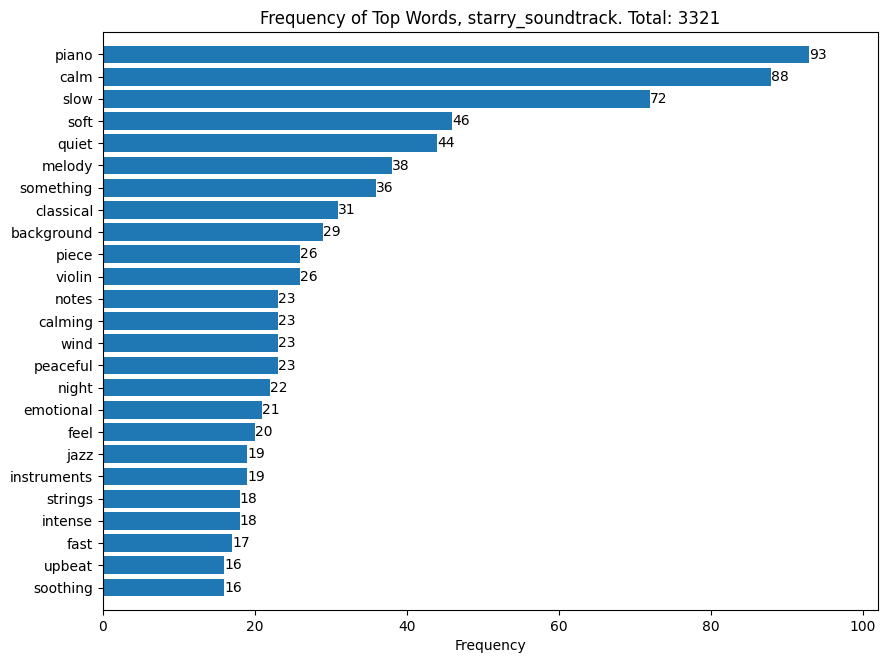

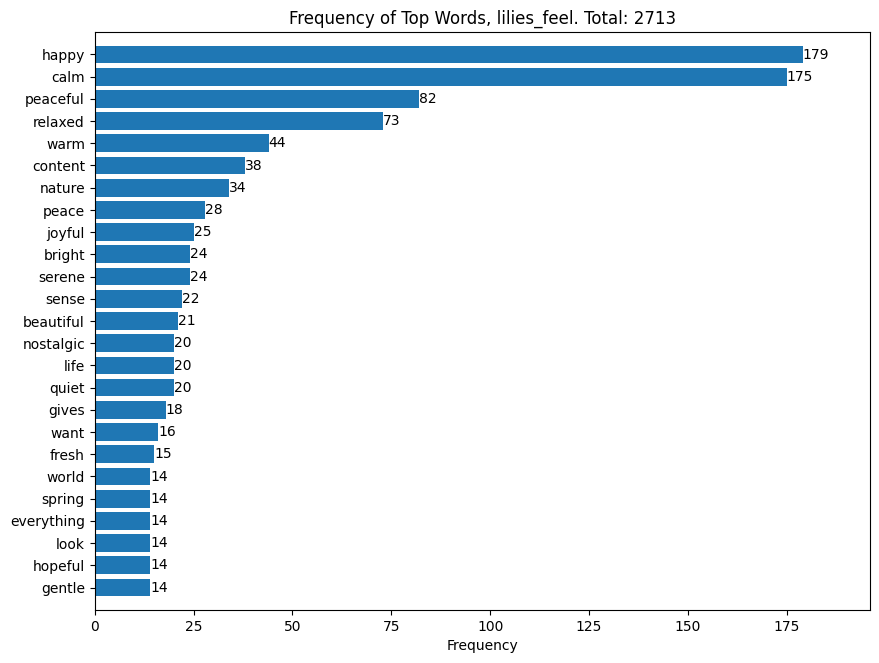

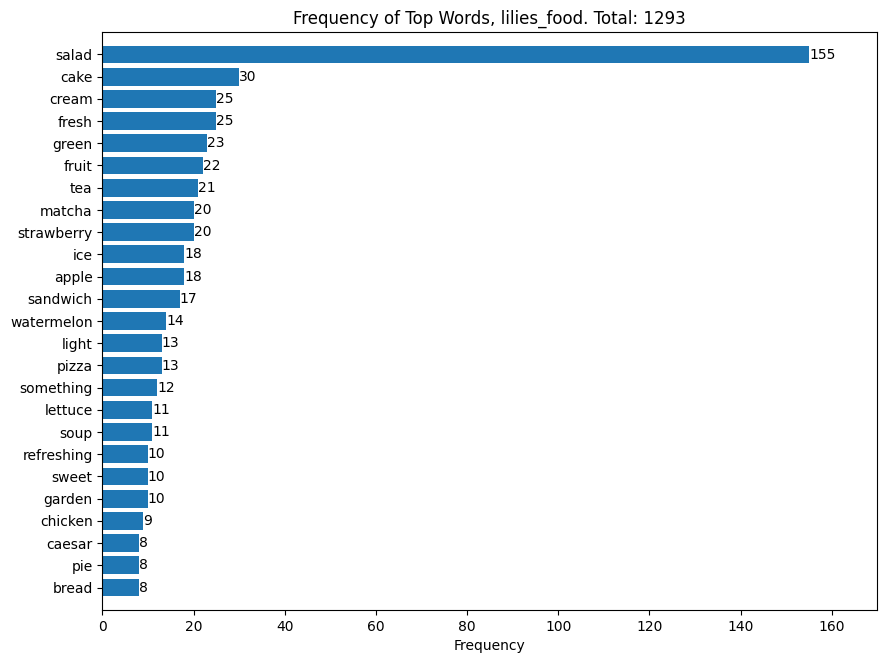

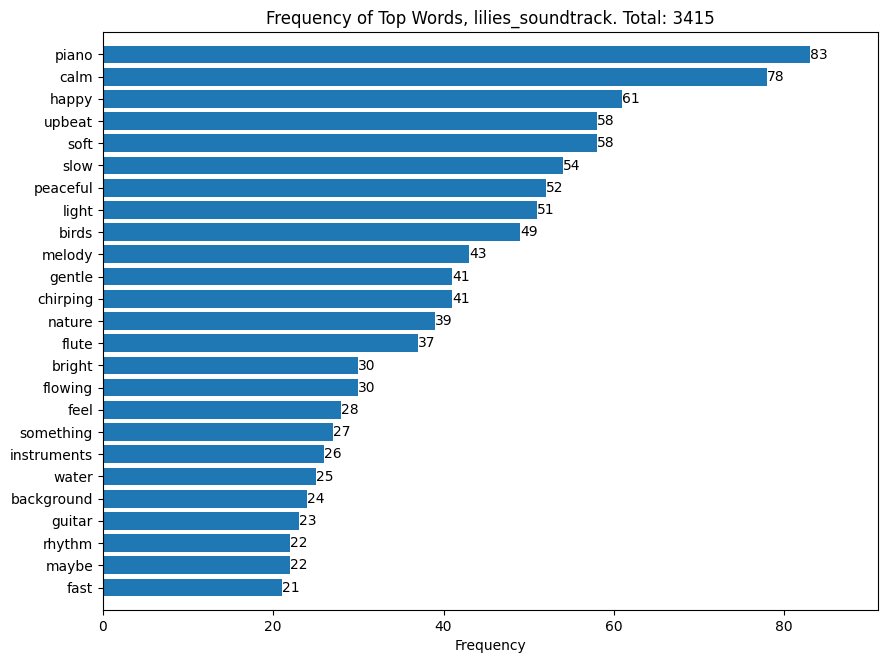

In [9]:
# create some histograms showing the most common words
base = set(['yourselves', 'as', 'only', 'i', 'no', 'so', 'this', 'www', "shed", 'all', 'you', 'shall', 'just', "theyll", 'own', "werent", 'your', "wed", 'for', "hows", "mustnt", "its", "youve", 'most', "didnt", 'a', 'over', "havent", "shouldnt", "hes", 'the', 'under', 'each', "thats", 'cannot', 'he', 'down', 'because', "arent", 'both', 'what', 'further', "whys", "whens", "theyre", 'or', 'up', 'their', 'how', 'himself', 'me', 'myself', 'him', 'on', 'to', "ill", "hell", 'be', 'k', 'she', 'out', 'them', "were", 'during', "couldnt", 'does', 'her', 'into', 'ourselves', 'having', 'by', "hed", "wont", "wheres", 'an', 'before', "im", 'am', 'other', 'there', 'but', "isnt", "id", 'otherwise', "shes", 'in', 'few', 'ours', 'of', "weve", 'not', "theres", "youd", 'and', 'ought', 'doing', 'between', 'did', 'than', "theyve", 'herself', "youll", "youre", 'com', 'should', 'been', "shell", 'hence', "well", 'at', 'such', 'theirs', 'http', 'again', 'some', 'my', 'else', 'against', "hadnt", "heres", "whats", 'more', 'below', 'any', 'after', 'these', 'off', "doesnt", 'can', 'who', "theyd", 'from', 'here', 'why', 'was', 'very', 'with', 'therefore', 'like', 'had', 'has', 'nor', 'its', 'those', "wouldnt", 'which', 'same', "wasnt", 'itself', 'would', 'above', 'while', 'when', 'however', 'is', 'our', 'where', 'yours', 'about', 'if', 'through', 'since', 'ever', 'do', 'themselves', 'r', "cant", 'have', 'also', 'hers', 'we', 'until', 'it', 'whom', 'could', 'get', 'yourself', 'too', "dont", "lets", 'being', "whos", "ive", 'were', "shant", 'are', 'then', "hasnt", 'once', 'they', 'his', 'that'])
N = 25

for column_name, output_file in output_files:
  painting = re.search(r"text/([^/]+)\.txt", output_file).group(1)

  counts, total = get_counts(column_name, output_file)

  # take the top N words
  counts_lst = list(counts.items())
  top_counts = sorted(counts_lst, reverse=True, key=lambda it: it[1])[:N]
  words = [c[0] for c in top_counts]
  nums = [c[1] for c in top_counts]
  xs = np.arange(N)

  fig_height = 0.3 * N
  fig, ax = plt.subplots(figsize=(10, fig_height))

  bar = ax.barh(xs, nums, height=0.8, align='center')
  ax.set_yticks(xs, labels=words)
  ax.set_ylim(-1, N)
  ax.invert_yaxis()
  ax.set_xlabel('Frequency')
  ax.set_title(f'Frequency of Top Words, {painting}. Total: {total}')

  ax.bar_label(bar, fmt='%d')
  ax.set_xlim(right=int(nums[0] * 1.1))
  plt.show()


In [27]:
def counts(in_df, title):
  stopwords = set(base)
  stopwords.update(general_ignore)
  for word in title.strip('.,!?()[]{}"\'').split():
    stopwords.add(word)

  if "feel" in title:
    stopwords.update(feel_ignore)
  elif "food" in title:
    stopwords.update(food_ignore)
  else:
    stopwords.update(music_ignore)

  counts = dict()
  total = 0
  for line in in_df.dropna():
    for w in line.split():
      w_clean = re.sub(r"[^\w\s]", "", w.strip().lower())
      if w_clean in stopwords or w_clean == '':
        continue

      if w_clean not in counts:
        counts[w_clean] = 0
      counts[w_clean] += 1
      total += 1

  return counts, total

# Creates the weight mappings for the given dataset and writes a file to the
# output directory for each one
def create_mapping(in_df, out_dir):
  clocks = in_df[in_df['Painting'] == 'The Persistence of Memory']
  starry = in_df[in_df['Painting'] == 'The Starry Night']
  lilies = in_df[in_df['Painting'] == 'The Water Lily Pond']

  cols = [
      ("Describe how this painting makes you feel.", "feels"),
      ("If this painting was a food, what would be?", "food"),
      ("Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.", "music")]

  # compute counts for each painting and each question
  for df, title in [(clocks, "clocks"), (starry, "starry"), (lilies, "lilies")]:
    for col, col_title in cols:
      col_df = df[col]
      counts_dir, total = counts(col_df, col)
      with open(f'{out_dir}/{title}-{col_title}.txt', 'w') as fp:
        for k in counts_dir:
          fp.write(f'{k} {str(counts_dir[k] / total)}\n')

# Load weights for each painting
def load_weights(weight_dir):
  dir_lst = []

  for paint in ["clocks", "starry", "lilies"]:
    for quest in ["feels", "food", "music"]:
      d = {}
      with open(f"{weight_dir}/{paint}-{quest}.txt", 'r') as fp:
        for line in fp:
          sline = line.split()
          word = sline[0]
          weight = float(sline[1])
          d[word] = weight
      dir_lst.append(d)

  return dir_lst



# Function to process text inputs into features
# Will take a pandas dataframe of size 3N x M, where N is the number of unique
# entries and M is the number of questions.
#
# Weight dir is the directory cotaining the weight mappings for each painting.
#
# Will return a new dataframe of size 2N x (M + 6). It will remove the three
# text-based questions (feels, food, music) and replace each with three features
# representing how much a given answer relates to each painting's responses
def process_text(in_df, weight_dir):
  feels = in_df['Describe how this painting makes you feel.']
  food = in_df['If this painting was a food, what would be?']
  music = in_df['Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.']
  new_df = in_df.drop(columns = ['Describe how this painting makes you feel.',
                                 'If this painting was a food, what would be?',
                                 'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.'])

  qs = [
      (feels, 'feels', 'Describe how this painting makes you feel.'),
      (food, 'food', 'If this painting was a food, what would be?'),
      (music, 'music', 'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.')
      ]

  dir_lst = load_weights(weight_dir)
  stopwords = set(base)
  stopwords.update(general_ignore)

  i = 0
  for painting in ['clock', 'starry', 'lilies']:
    for df, quest, t in qs:
      dir = dir_lst[i]
      new_col = []
      no_words = stopwords.copy()

      for word in t.strip('.,!?()[]{}"\'').split():
        no_words.add(word)
      if "feel" in t:
        no_words.update(feel_ignore)
      elif "food" in t:
        no_words.update(food_ignore)
      else:
        no_words.update(music_ignore)

      for line in df.dropna():
        val = 0.0
        for w in line.split():
          w_clean = re.sub(r"[^\w\s]", "", w.strip().lower())
          if w_clean in stopwords or w_clean == '':
            continue
          if w_clean in dir:
            val += dir[w_clean]
        new_col.append(val)

      # hacky way to set column name variably
      new_col_name = f"{painting}-{quest}"
      new_df = new_df.assign(**{new_col_name: pd.Series(new_col)})
      i+=1

  return new_df

WDIR = "weights"
#create_mapping(trainval_df, WDIR)
out_df = process_text(trainval_df, WDIR)


Index(['unique_id', 'Painting',
       'On a scale of 1–10, how intense is the emotion conveyed by the artwork?',
       'This art piece makes me feel sombre.',
       'This art piece makes me feel content.',
       'This art piece makes me feel calm.',
       'This art piece makes me feel uneasy.',
       'How many prominent colours do you notice in this painting?',
       'How many objects caught your eye in the painting?',
       'How much (in Canadian dollars) would you be willing to pay for this painting?',
       'If you could purchase this painting, which room would you put that painting in?',
       'If you could view this art in person, who would you want to view it with?',
       'What season does this art piece remind you of?', 'clock-feels',
       'clock-food', 'clock-music', 'starry-feels', 'starry-food',
       'starry-music', 'lilies-feels', 'lilies-food', 'lilies-music'],
      dtype='object')


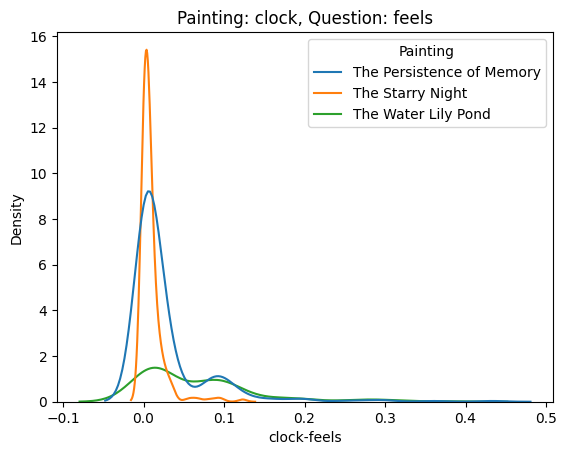

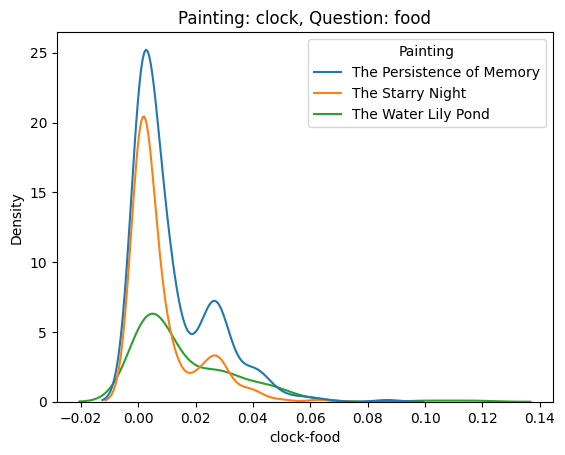

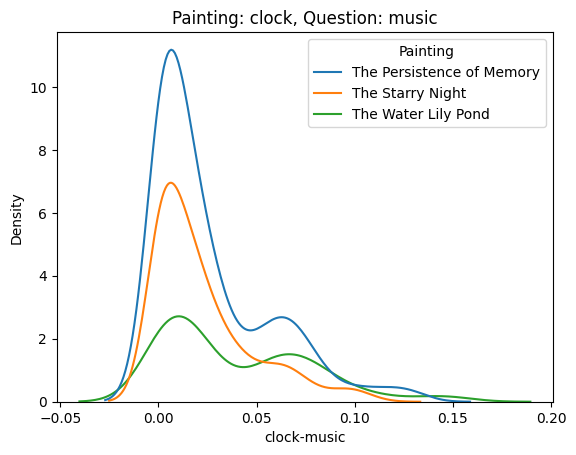

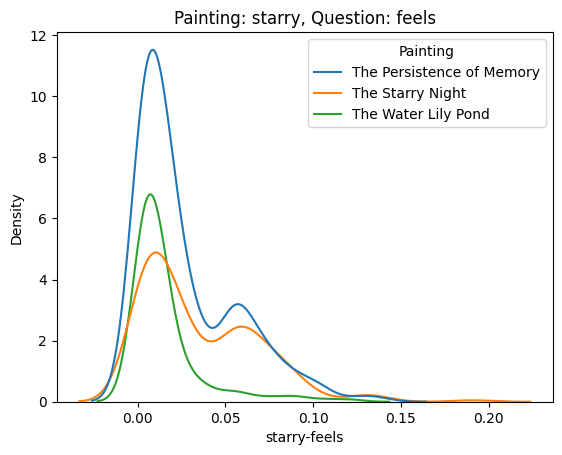

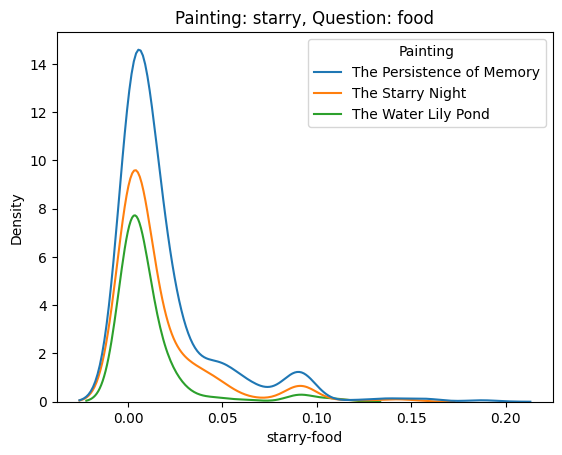

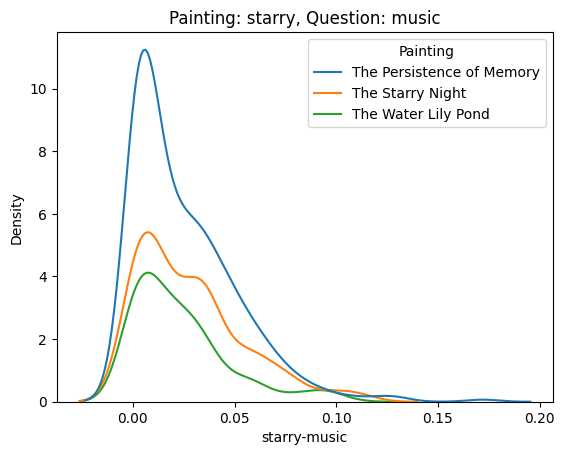

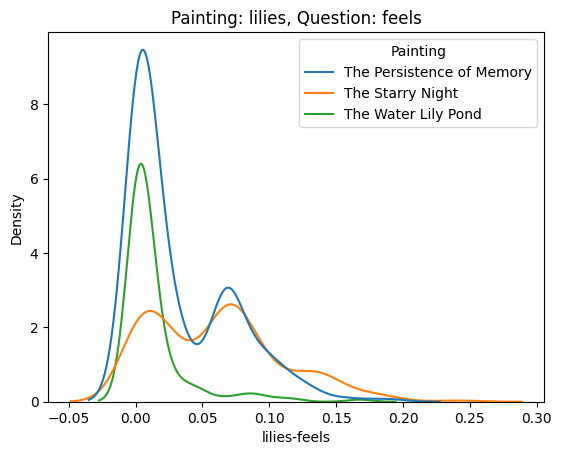

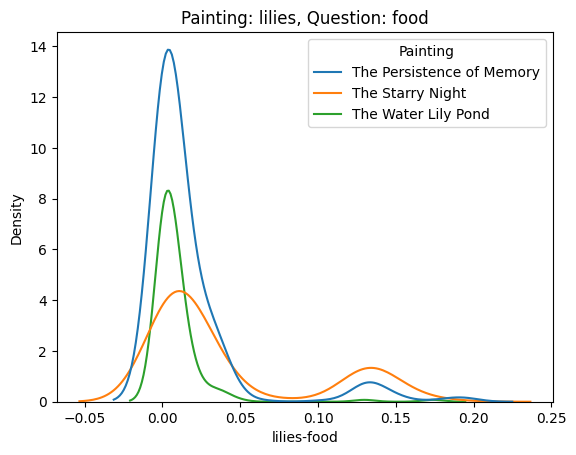

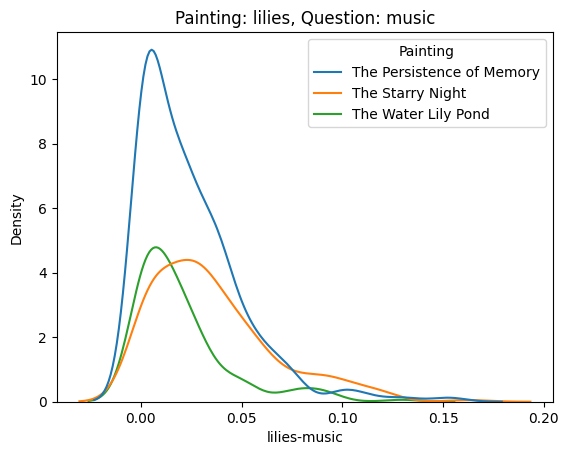

In [28]:
import seaborn as sns

# plot the text-derived columns for each painting
def plot_text_feats(in_df):
  for painting in ['clock', 'starry', 'lilies']:
    for quest in ['feels', 'food', 'music']:
      fig, ax = plt.subplots()
      sns.kdeplot(in_df, x=f'{painting}-{quest}', hue="Painting", ax=ax)
      plt.title(f"Painting: {painting}, Question: {quest}")
      plt.show()
      plt.close()

plot_text_feats(out_df)
